In [1]:
import rich
import logging
import glob

import matplotlib.pyplot as plt
import time
import os
import awkward as ak
import numpy as np
import pandas as pd
from lgdo import lh5
from legendmeta import LegendMetadata
from dbetto import Props
from pygama.pargen.AoE_cal import *
from pygama.pargen.AoE_cal import CalAoE, Pol1, SigmaFit, aoe_peak
from pygama.pargen.data_cleaning import get_tcm_pulser_ids
from pygama.pargen.utils import load_data
from tqdm import tqdm

%matplotlib inline

logging.basicConfig(level=logging.INFO)
logging.getLogger('numba').setLevel(logging.INFO)
logging.getLogger('parse').setLevel(logging.INFO)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/conda/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/opt/conda/lib/python3.12/site-packages/tornado

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



# Path to data

In [2]:
data_path = "/global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/v2.1.5"
config = Props.read_from(os.path.join(data_path, "config.json"), subst_pathvar=True)["setups"]["l200"]["paths"]
meta  = LegendMetadata(config["metadata"])
chmap = meta.channelmap(meta.dataprod.runinfo.p03.r000.phy.start_key)

In [3]:
# Qui posso veedere quale è la versione giusta di hit (o altro che mis erve)
# a cui punta il mio file di config ovvero, in questo caso, la versione v2..1.5 e dalla quale posso caricare per gli studi dei QC

config['tier_pet']

'/global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/v2.1.5/generated/tier/pet'

# Get files

In [4]:
# PRENDO I DATI DI FISICA E NON DI CALIBRAZIONE f"{config["tier_psp"]}/cal/p03/r000/*.lh5" ---> f"{config["tier_psp"]}/phy/p03/r000/*.lh5"
pet_files = sorted(glob.glob(f"{config["tier_pet"]}/phy/l200-p03-r000-phy-tier_pet.lh5"))
psp_files = sorted(glob.glob(f"{config["tier_psp"]}/phy/p03/r000/*.lh5")) #access exsiting DSP-processed data such as the energy for partitions
tcm_files = sorted(glob.glob(f"{config["tier_tcm"]}/phy/p03/r000/*.lh5"))  # --> solo per il pulse
raw_files = sorted(glob.glob(f"{config["tier_raw"]}/phy/p03/r000/*.lh5"))

In [5]:
channel = f'ch{chmap.V02160A.daq.rawid}'
detector = "V02160A"
channel

'ch1104000'

In [6]:
# The cal_dict we can pull from a hit_results file generated by the dataflow

cal_file = f"{config["par_pht"]}/cal/p03/r000/l200-p03-r000-cal-20230311T235840Z-par_pht.json"
cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"]



# PSP files

In [7]:
params = [ 't_sat_lo',
        "bl_slope_rms",
    "cuspEmax_ctc_cal",
    "is_valid_bl_slope_rms",
    ]


In [8]:
# qui mi posso salvare i paramteri di DSP (che ho scelto e definito in config) per lo specfico canale e per tutti gli eventi registrati
cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"]
data, threshold_masks= load_data(
        files = psp_files,   # da qui prenidmao i dati di dsp già processati 
        lh5_path = f"{channel}/dsp",  # prendo i risultati del dsp per il canale /detcetor specifico
        cal_dict = cal_dict,  # lo prendiamo da par_pht
        params=params,
        #threshold=5,
        return_selection_mask=True,)

In [9]:
# trigger
trigger_data = lh5.read_as("/evt/trigger", pet_files, library="ak")
data["forced_trigger"] = ak.to_numpy(trigger_data['is_forced'])
# ==========================================
# pulser
# Load in coincidence information. This tells us if an event was a pulser, ged, or spm event
coincident_data = lh5.read_as("/evt/coincident", pet_files, library="ak")
#data["is_pulser"] = mask
data["is_pulser"] = coincident_data['puls']  # no pulser events
data["is_muon"] = coincident_data['muon_offline']  # no muons
data["is_HPGe"] = coincident_data['geds']  # only events with an HPGe signal
# ============================================
# low enegy
mask_lowe = (data["cuspEmax_ctc_cal"] > 25) & (data["cuspEmax_ctc_cal"] < 500)
data["is_below_500keV"] = mask_lowe

In [10]:
a_class = cal_dict["is_valid_bl_slope_rms_classifier"]['parameters']['a']
b_class = cal_dict["is_valid_bl_slope_rms_classifier"]['parameters']['b']


classifier = (data["bl_slope_rms"] - a_class) / b_class

mask_class = (classifier > cal_dict["is_valid_bl_slope_rms"]["parameters"]["a"]) & \
       (classifier < cal_dict["is_valid_bl_slope_rms"]["parameters"]["b"])

data["is_valid_classifier_bl_slope_rms"] = mask_class

In [11]:
# discharge
mask_discharge = data['t_sat_lo']>0
data["is_discharge"] = mask_discharge

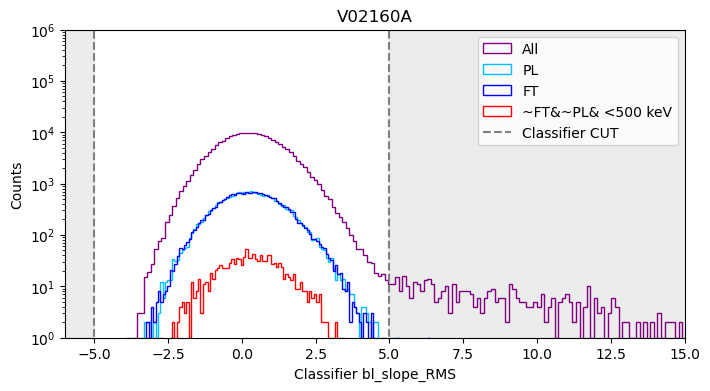

In [12]:

plt.figure(figsize = (8,4))
plt.hist((data.query('~is_discharge')["bl_slope_rms"]-a_class)/b_class, bins = 250, range = (-5, 25), color = 'purple', histtype = 'step', label = 'All')
plt.hist((data.query("~is_discharge&is_pulser")["bl_slope_rms"]-a_class)/b_class, bins = 250, range = ( -5, 15), color = "deepskyblue", histtype = 'step', label = 'PL')
plt.hist((data.query("~is_discharge&forced_trigger")["bl_slope_rms"]-a_class)/b_class, bins = 250, range = ( -5, 15), color = "blue", histtype = 'step', label = 'FT')
plt.hist((data.query("~is_discharge&~forced_trigger&~is_pulser&is_below_500keV")["bl_slope_rms"]-a_class)/b_class, bins = 250, range = ( -5, 15), color = "red", histtype = 'step', label = '~FT&~PL& <500 keV')

plt.vlines(-5, 0, 1e6, ls = '--', color = 'grey' )
plt.vlines(5, 0, 1e6, ls = '--', color = 'grey', label = 'Classifier CUT' )
plt.ylim(1, 1e6)
plt.xlim(-6, 15)
plt.legend(loc = 'upper right')
plt.ylabel(f"Counts")
plt.xlabel(f"Classifier bl_slope_RMS")
plt.axvspan(-25, -5, color = 'grey', alpha=0.15)
plt.axvspan(5,25, color = 'grey', alpha=0.15)
plt.title(f"{detector}")
plt.yscale('log')
plt.savefig("bl_slope_RMS_class.svg", dpi = 600)

In [13]:
data

,bl_slope,bl_slope_rms,cuspEmax,cuspEmax_ctc,cuspEmax_ctc_cal,is_valid_bl_slope,is_valid_bl_slope_rms,t_sat_lo,forced_trigger,is_pulser,is_muon,is_HPGe,is_below_500keV,is_valid_classifier_bl_slope_rms,is_discharge
0,0.016286,12.670416,0.320338,NaN,NaN,True,True,0.0,False,False,False,True,False,True,False
1,0.017787,12.584935,4.296205,4.296067,0.035374,True,True,0.0,False,False,False,True,False,True,False
2,-0.004746,12.783596,2.403704,2.403815,-0.257466,True,True,0.0,False,False,False,True,False,True,False
3,0.019171,12.077505,1.586369,1.583160,-0.384468,True,True,0.0,False,False,False,True,False,True,False
4,0.004323,12.946972,4.474205,4.473058,0.062765,True,True,0.0,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214041,-0.024594,11.275720,-0.864503,-0.861656,-0.762822,True,True,0.0,False,False,False,True,False,True,False
214042,-0.011811,12.153982,3.751267,3.749321,-0.049239,True,True,0.0,False,False,False,True,False,True,False
214043,-0.004945,11.519229,5.946424,5.940003,0.289785,True,True,0.0,False,False,False,True,False,True,False
214044,-0.020248,11.674230,4.030265,4.021709,-0.007085,True,True,0.0,False,False,False,True,False,True,False


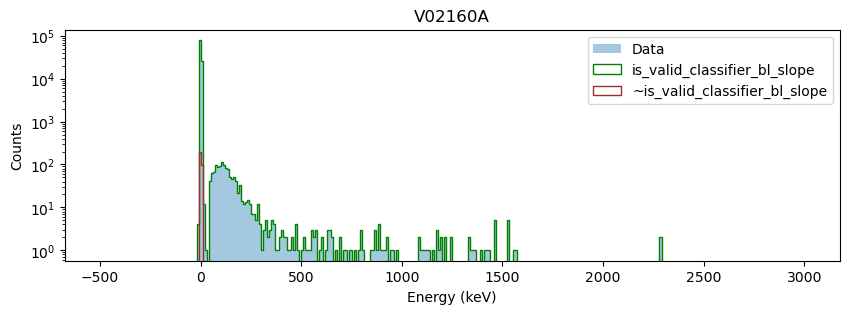

In [20]:
plt.figure(figsize = (10,3))

emin = -500
emax = 3000
bins = int((emax-emin)/10)

ene = data["cuspEmax_ctc_cal"]

# thesee should be default cuts
m_discharge = ~data["is_discharge"]
m_pulser = data["is_pulser"]
m_ft = data["forced_trigger"]
m_coincidence = data["is_HPGe"]&~data["is_muon"]
# low energy and classifier
m_lowE = data["is_below_500keV"]
m_slope_rms = data["is_valid_classifier_bl_slope_rms"]

plt.hist(ene[m_discharge & m_coincidence &  ~m_pulser & ~m_ft], bins = bins, range = (emin, emax), alpha = 0.4, label = 'Data')

plt.hist(ene[m_discharge & m_coincidence &  ~m_pulser & ~m_ft & m_slope_rms], color = 'green', bins = bins, range = (emin, emax), histtype = 'step', label = 'is_valid_classifier_bl_slope')
plt.hist(ene[m_discharge & m_coincidence &  ~m_pulser & ~m_ft &  ~m_slope_rms], color = 'brown', bins = bins, range = (emin, emax), histtype = 'step', label = '~is_valid_classifier_bl_slope')
plt.legend(loc = 'upper right')
plt.ylabel(f"Counts")
plt.xlabel(f"Energy (keV)")
plt.title(f"{detector}")
plt.yscale('log')
